# Data Preparation

In [ ]:
import numpy as np
import torch
import random

def reproducibility(seed: int):
    """
    Set seed for experiment reproducibility

    :param seed: seed
    """

    # for torch
    torch.manual_seed(seed)

    # for numpy
    np.random.seed(seed)

    # for random
    random.seed(seed)

    # for cuda
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False


In [ ]:
reproducibility(42)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
from scipy.stats import skew, kurtosis, chi2_contingency, ttest_ind

# Define the directory containing the mammogram images
image_dir = '/home/castrechini/projects/bac_project/dataset/processed_hbb/exams_with_vascular_calcs'
# image_dir = '/home/castrechini/projects/bac_project/dataset/34_bac_5000_mammo'


# List all image files in the directory
image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]

# Extract patient ID, view, and side from the file names
data = []
for file in image_files:
    patient_id = file[:10]
    view = file[10]
    side = file[11]
    filepath = os.path.join(image_dir, file)
    try:
        with Image.open(filepath) as img:
            width, height = img.size
    except:
        width, height = None, None
    data.append((patient_id, view, side, file, width, height))

# Create a DataFrame from the extracted data
df = pd.DataFrame(data, columns=['Patient_ID', 'View', 'Side', 'Filename', 'Width', 'Height'])

# Display basic information about the dataset
print("Number of images:", len(df))
print("Number of unique patients:", df['Patient_ID'].nunique())
print("Distribution of views:\n", df['View'].value_counts())
print("Distribution of sides:\n", df['Side'].value_counts())

# Check for missing data
print("Missing values:\n", df.isnull().sum())

# Plot the distribution of views
plt.figure(figsize=(10, 5))
sns.countplot(x='View', data=df, palette='viridis')
plt.title('Distribution of Views')
plt.xlabel('View')
plt.ylabel('Count')
plt.show()

# Plot the distribution of sides
plt.figure(figsize=(10, 5))
sns.countplot(x='Side', data=df, palette='viridis')
plt.title('Distribution of Sides')
plt.xlabel('Side')
plt.ylabel('Count')
plt.show()

# Distribution of images per patient
patient_counts = df['Patient_ID'].value_counts()
plt.figure(figsize=(10, 5))
sns.histplot(patient_counts, bins=range(1, patient_counts.max() + 1), kde=False)
plt.title('Distribution of Images per Patient')
plt.xlabel('Number of Images')
plt.ylabel('Number of Patients')
plt.show()

# Plot image dimensions
plt.figure(figsize=(10, 5))
sns.histplot(df['Width'].dropna(), kde=True, color='blue', label='Width')
sns.histplot(df['Height'].dropna(), kde=True, color='orange', label='Height')
plt.title('Distribution of Image Dimensions')
plt.xlabel('Dimension (pixels)')
plt.ylabel('Count')
plt.legend()
plt.show()

# Pair plot for dimensions
sns.pairplot(df[['Width', 'Height']].dropna())
plt.suptitle('Pair Plot of Image Dimensions', y=1.02)
plt.show()

# Heatmap of correlations (if any other numerical features exist)
correlation_matrix = df[['Width', 'Height']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Advanced box plot for image dimensions
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Width', 'Height']].dropna())
plt.title('Box Plot of Image Dimensions')
plt.ylabel('Dimension (pixels)')
plt.show()

# Summary statistics for numerical features
print("Summary statistics for image dimensions:")
print(df[['Width', 'Height']].describe())

# Skewness and kurtosis
print("Skewness of Width:", skew(df['Width'].dropna()))
print("Kurtosis of Width:", kurtosis(df['Width'].dropna()))
print("Skewness of Height:", skew(df['Height'].dropna()))
print("Kurtosis of Height:", kurtosis(df['Height'].dropna()))

# Distribution plots
# plt.figure(figsize=(10, 5))
# sns.histplot(df['Width'].dropna(), kde=True, color='blue', label='Width')
# sns.histplot(df['Height'].dropna(), kde=True, color='orange', label='Height')
# plt.title('Distribution of Image Dimensions')
# plt.xlabel('Dimension (pixels)')
# plt.ylabel('Count')
# plt.legend()
# plt.show()

# Box plot to detect outliers
# plt.figure(figsize=(10, 5))
# sns.boxplot(data=df[['Width', 'Height']].dropna())
# plt.title('Box Plot of Image Dimensions')
# plt.ylabel('Dimension (pixels)')
# plt.show()

# Chi-Square test for association between View and Side
contingency_table = pd.crosstab(df['View'], df['Side'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Test between View and Side:")
print(f"Chi2: {chi2}, p-value: {p}")

# T-Test to compare mean Width and Height between left and right side images
left_side = df[df['Side'] == 'l']
right_side = df[df['Side'] == 'r']
t_stat_width, p_value_width = ttest_ind(left_side['Width'].dropna(), right_side['Width'].dropna())
t_stat_height, p_value_height = ttest_ind(left_side['Height'].dropna(), right_side['Height'].dropna())
print("T-Test for Width between left and right sides:")
print(f"T-statistic: {t_stat_width}, p-value: {p_value_width}")
print("T-Test for Height between left and right sides:")
print(f"T-statistic: {t_stat_height}, p-value: {p_value_height}")

# Show first few rows of the DataFrame
print("First few rows of the DataFrame:")
print(df.head())


In [ ]:
import os

# Path to the main folder
main_folder_path = '/home/castrechini/projects/bac_project/dataset/processed_hbb_5000'

# Iterate over the files in the main folder
for filename in os.listdir(main_folder_path):
    file_path = os.path.join(main_folder_path, filename)
    # Check if it is a file and if it has a .png extension
    if os.path.isfile(file_path) and filename.endswith('.png'):
        os.remove(file_path)
        print(f"Deleted: {file_path}")


In [ ]:
import os
import shutil

# Define the paths
main_folder = '/home/castrechini/projects/bac_project/dataset/processed_hbb_5000'
train_folder = os.path.join(main_folder, 'train', '1')
val_folder = os.path.join(main_folder, 'val', '1')

# Create a list of folders to process
folders_to_process = [train_folder, val_folder]

# Copy files from train/1 and val/1 to the main folder
for folder in folders_to_process:
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)
        if os.path.isfile(file_path):
            shutil.copy(file_path, main_folder)
            print(f"Copied {filename} to {main_folder}")

print("All files have been copied.")


In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from collections import defaultdict

def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def get_patient_id(filename):
    return filename[:10]

def get_files_and_labels(root_dir):
    files = []
    labels = []
    patient_to_label = defaultdict(list)
    for label in ['cases_not_checked_for_bac', 'exams_with_vascular_calcs']:
        folder_path = os.path.join(root_dir, label)
        for file in os.listdir(folder_path):
            if file.endswith('.png'):
                files.append(os.path.join(folder_path, file))
                labels.append(label)
                patient_id = get_patient_id(file)
                patient_to_label[patient_id].append(label)
    return files, labels, patient_to_label

def stratified_split(patient_to_label, test_size=0.2, random_state=42):
    # Get unique patient IDs and their corresponding labels
    patient_ids = list(patient_to_label.keys())
    patient_labels = [patient_to_label[pid][0] for pid in patient_ids]  # Assuming all labels for a patient are the same

    # Stratified split on unique patient IDs
    train_ids, val_ids = train_test_split(patient_ids, test_size=test_size, random_state=random_state, stratify=patient_labels)
    
    return train_ids, val_ids

def copy_files(files, root_dst, patient_ids):
    for file in tqdm(files, desc=f'Copying files to {root_dst}'):
        if get_patient_id(os.path.basename(file)) in patient_ids:
            # Determine the label from the file path
            label = 'cases_not_checked_for_bac' if 'cases_not_checked_for_bac' in file else 'exams_with_vascular_calcs'
            # Create destination path
            dst = os.path.join(root_dst, label)
            create_dir(dst)
            # Copy file
            shutil.copy(file, dst)

def main():
    root_dir = '/home/castrechini/projects/bac_project/dataset/processed_hbb'
    train_dir = os.path.join(root_dir, 'train')
    val_dir = os.path.join(root_dir, 'val')
    
    # Create train and val directories with subdirectories
    create_dir(os.path.join(train_dir, 'cases_not_checked_for_bac'))
    create_dir(os.path.join(train_dir, 'exams_with_vascular_calcs'))
    create_dir(os.path.join(val_dir, 'cases_not_checked_for_bac'))
    create_dir(os.path.join(val_dir, 'exams_with_vascular_calcs'))
    
    # Get files and labels
    files, labels, patient_to_label = get_files_and_labels(root_dir)
    
    # Perform stratified split based on patient IDs
    train_ids, val_ids = stratified_split(patient_to_label)
    
    # Copy files to the respective directories with progress bars
    copy_files(files, train_dir, train_ids)
    copy_files(files, val_dir, val_ids)
    
    print("Files have been split and copied successfully.")

if __name__ == "__main__":
    main()


In [ ]:
import os
import pandas as pd

bac_folder = '/home/castrechini/projects/bac_project/dataset/processed_hbb/exams_with_vascular_calcs'
other_folder = '/home/castrechini/projects/bac_project/dataset/processed_hbb/cases_not_checked_for_bac'

# Function to check if the image exists and return its path
def get_image_path(patient_id, side, view, folder_path):
    image_name = f"{patient_id}{view}{side}.png"
    image_path = os.path.join(folder_path, image_name)
    if os.path.isfile(image_path):
        return image_path
    else:
        return None

# Load and process images for patients with BAC
bac_data = []
for image_name in os.listdir(bac_folder):
    if image_name.endswith('.png'):  # Check if the file is an image
        patient_id = image_name[:10]
        view = image_name[10]
        side = image_name[11]
        image_path = get_image_path(patient_id, side, view, bac_folder)
        if image_path:
            bac_data.append((image_path, patient_id, side, view, 1))

# Load and process images for patients without BAC
other_data = []
for image_name in os.listdir(other_folder):
    if image_name.endswith('.png'):  # Check if the file is an image
        patient_id = image_name[:10]
        view = image_name[10]
        side = image_name[11]
        image_path = get_image_path(patient_id, side, view, other_folder)
        if image_path:
            other_data.append((image_path, patient_id, side, view, 0))

# Combine data for patients with and without BAC
all_data = bac_data + other_data

# Create a DataFrame
data = pd.DataFrame(all_data, columns=['image_path', 'patient_id', 'breast_side', 'view', 'label'])

# Save the DataFrame to a CSV file
data.to_csv('patients.csv', index=False)


In [ ]:
import os
import pandas as pd

# Define the directory containing the mammogram images
image_folder = '/home/castrechini/projects/bac_project/dataset/34_bac_5000_mammo'

# Function to check if the image exists and return its path
def get_image_path(patient_id, side, view, folder_path):
    image_name = f"{patient_id}{view}{side}.png"
    image_path = os.path.join(folder_path, image_name)
    if os.path.isfile(image_path):
        return image_path
    else:
        return None

# Load and process images from the folder
data = []
for image_name in os.listdir(image_folder):
    if image_name.endswith('.png'):  # Check if the file is an image
        patient_id = image_name[:10]
        view = image_name[10]
        side = image_name[11]
        image_path = get_image_path(patient_id, side, view, image_folder)
        if image_path:
            data.append((image_path, patient_id, side, view))

# Create a DataFrame
df = pd.DataFrame(data, columns=['image_path', 'patient_id', 'breast_side', 'view'])

# Save the DataFrame to a CSV file
df.to_csv('all_patients.csv', index=False)

print("Data saved to 'all_patients.csv'")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")


# Pie Chart of Label Distribution
plt.figure(figsize=(8, 6))
labels_count = data['label'].value_counts()
plt.pie(labels_count, labels=labels_count.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Labels')
plt.axis('equal')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
data = pd.read_csv('all_patients.csv')

# Count the number of images for each patient
image_counts = data['patient_id'].value_counts()

# Count the number of patients for each count of images
patients_count = image_counts.value_counts().sort_index()

# Calculate the percentage of patients for each count of images
total_patients = patients_count.sum()
percentage_patients = (patients_count / total_patients) * 100

# Plotting
plt.figure(figsize=(10, 6))

# Define colors for bars
colors = ['blue', 'green', 'orange', 'red']  # Add more colors as needed

# Plot the bar chart with differentiated colors
bar_plot = patients_count.plot(kind='bar', color=colors)

# Add the number of patients and percentage to each bar
for index, value in enumerate(patients_count):
    plt.text(index, value + 0.2, f"{value}\n({percentage_patients.iloc[index]:.2f}%)", ha='center')

plt.title('Number of Patients by Number of Images')
plt.xlabel('Number of Images')
plt.ylabel('Number of Patients')
plt.grid(axis='y')
plt.show()



In [ ]:
import pandas as pd

# Load the CSV file
data = pd.read_csv('all_patients.csv')

# Count the number of images for each patient
image_counts = data['patient_id'].value_counts()

# Find patient IDs with 8 images
patients_with_8_images = image_counts[image_counts == 1]

# Print the patient IDs
print("Patient IDs with 8 images:")
print(patients_with_8_images.index.tolist())


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
data = pd.read_csv('patients.csv')

# Count the number of patients for each label
label_counts = data.drop_duplicates('patient_id')['label'].value_counts()

# Plotting
plt.figure(figsize=(8, 5))

# Plot the bar chart
bar_plot = label_counts.plot(kind='bar', color=['blue', 'green'])

# Add the count of patients to each bar
for index, value in enumerate(label_counts):
    plt.text(index, value + 0.2, f"{value}", ha='center')

plt.title('Number of Patients by Label')
plt.xlabel('Label')
plt.ylabel('Number of Patients')
plt.xticks(range(len(label_counts.index)), ['Label 0', 'Label 1'])
plt.grid(axis='y')
plt.show()

# Print the number of patients with label 0 and label 1
print("Number of patients with label 0:", label_counts.get(0, 0))
print("Number of patients with label 1:", label_counts.get(1, 0))


In [ ]:
import os
import pandas as pd
import cv2

# Directory paths
neg_dir = 'dataset/cases_not_checked_for_bac/'
pos_dir = 'dataset/exams_with_vascular_calcs/'

# Process negative images
data_neg = pd.DataFrame({'image_name': os.listdir(neg_dir), 'BAC': 0})
data_neg.to_csv('annotations_neg.csv', index=False)

# Process positive images
data_pos = pd.DataFrame({'image_name': os.listdir(pos_dir), 'BAC': 1})
data_pos.to_csv('annotations_pos.csv', index=False)


In [ ]:
import os
import pandas as pd
import cv2
from concurrent.futures import ThreadPoolExecutor

# Directory paths
neg_dir = '/home/castrechini/projects/bac_project/dataset/cases_not_checked_for_bac'
pos_dir = '/home/castrechini/projects/bac_project/dataset/exams_with_vascular_calcs'

# Function to load and get dimensions of an image
def get_image_dimensions(img_path):
    img_array = cv2.imread(img_path)
    height, width, _ = img_array.shape
    return height, width

# Function to calculate descriptive statistics
def calculate_statistics(directory):
    image_paths = [os.path.join(directory, img) for img in os.listdir(directory)]
    with ThreadPoolExecutor() as executor:
        dimensions = executor.map(get_image_dimensions, image_paths)
    
    heights, widths = zip(*dimensions)
    image_df = pd.DataFrame({'height': heights, 'width': widths})
    return image_df.describe(percentiles=[.25, .5, .75, .90, .95])

# Calculate statistics for negative images
print("Statistics for negative images:")
neg_stats = calculate_statistics(neg_dir)
print(neg_stats)

# Calculate statistics for positive images
print("\nStatistics for positive images:")
pos_stats = calculate_statistics(pos_dir)
print(pos_stats)

# Function to calculate statistics for all images together
def calculate_combined_statistics(directories):
    all_dimensions = []
    for directory in directories:
        image_paths = [os.path.join(directory, img) for img in os.listdir(directory)]
        with ThreadPoolExecutor() as executor:
            dimensions = executor.map(get_image_dimensions, image_paths)
        all_dimensions.extend(dimensions)
    
    heights, widths = zip(*all_dimensions)
    image_df = pd.DataFrame({'height': heights, 'width': widths})
    return image_df.describe(percentiles=[.25, .5, .75, .90, .95])

# Calculate statistics for all images together
print("\nStatistics for all images:")
all_stats = calculate_combined_statistics([neg_dir, pos_dir])
print(all_stats)

# Save statistics to a CSV file
all_stats.to_csv('all_statistics.csv')

In [ ]:
# import os
# import pandas as pd

# class Patient:
#     def __init__(self, patient_id, cc_left_image_path, cc_right_image_path, mlo_left_image_path, mlo_right_image_path, label):
#         self.patient_id = patient_id
#         self.cc_left_image_path = cc_left_image_path
#         self.cc_right_image_path = cc_right_image_path
#         self.mlo_left_image_path = mlo_left_image_path
#         self.mlo_right_image_path = mlo_right_image_path
#         self.label = label

# data_dir_bac_pos = 'data/exams_with_vascular_calcs'
# data_dir_bac_neg = 'data/cases_not_checked_for_bac'
# csv_file = 'patients.csv'

# # Read the CSV file into a DataFrame
# df = pd.read_csv(csv_file)

# patient_data = []

# for index, row in df.iterrows():
#     patient_id = str(row['patient_id']).zfill(10)
#     label = row['label']
    
#     # Construct image paths based on patient ID and label for BAC+ patients
#     cc_left_image_path = os.path.join(data_dir_bac_pos, f'{patient_id}cl.png')
#     cc_right_image_path = os.path.join(data_dir_bac_pos, f'{patient_id}cr.png')
#     mlo_left_image_path = os.path.join(data_dir_bac_pos, f'{patient_id}ml.png')
#     mlo_right_image_path = os.path.join(data_dir_bac_pos, f'{patient_id}mr.png')
    
#     # If BAC+ images don't exist, try to find them in BAC- folder
#     if not os.path.exists(cc_left_image_path):
#         cc_left_image_path = os.path.join(data_dir_bac_neg, f'{patient_id}cl.png')
#     if not os.path.exists(cc_right_image_path):
#         cc_right_image_path = os.path.join(data_dir_bac_neg, f'{patient_id}cr.png')
#     if not os.path.exists(mlo_left_image_path):
#         mlo_left_image_path = os.path.join(data_dir_bac_neg, f'{patient_id}ml.png')
#     if not os.path.exists(mlo_right_image_path):
#         mlo_right_image_path = os.path.join(data_dir_bac_neg, f'{patient_id}mr.png')
    
#     # Check if image files exist before assigning paths
#     if not os.path.exists(cc_left_image_path):
#         cc_left_image_path = None
#     if not os.path.exists(cc_right_image_path):
#         cc_right_image_path = None
#     if not os.path.exists(mlo_left_image_path):
#         mlo_left_image_path = None
#     if not os.path.exists(mlo_right_image_path):
#         mlo_right_image_path = None
    
#     # Create a Patient instance and append to patient_data
#     patient_data.append(Patient(patient_id, cc_left_image_path, cc_right_image_path, mlo_left_image_path, mlo_right_image_path, label))

# # Now you have populated patient_data with instances representing each patient

In [ ]:
# # Print information for the first few patients
# for patient in patient_data[:]:  # Print information for the first 5 patients as an example
#     print("Patient ID:", patient.patient_id)
#     print("Label:", patient.label)
#     print("CC Left Image Path:", patient.cc_left_image_path)
#     print("CC Right Image Path:", patient.cc_right_image_path)
#     print("MLO Left Image Path:", patient.mlo_left_image_path)
#     print("MLO Right Image Path:", patient.mlo_right_image_path)
#     print()

# # Check the total number of patients
# print("Total number of patients:", len(patient_data))

# New Section

In [ ]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np


# Read the CSV file
csv_file = 'patients.csv'
data = pd.read_csv(csv_file)

# Convert patient IDs to strings with leading zeros
data['patient_id'] = data['patient_id'].astype(str).str.zfill(10)

# Modify the image path format
data['image_path'] = data['image_path'].str.replace('\\', '/')

# Extract patient IDs and labels
patient_ids = data['patient_id'].unique()
labels = data.groupby('patient_id')['label'].max().reset_index(drop=True)

# Shuffle patient IDs
# np.random.shuffle(patient_ids)

# Initialize StratifiedKFold with 3 folds
# skf = StratifiedKFold(n_splits=3, shuffle=False)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Create empty lists to store data across folds
train_data_list = []
test_data_list = []

# Split data into 3 folds while preserving label proportions and patient-level splitting
for fold, (train_index, test_index) in enumerate(skf.split(patient_ids, labels)):
    # Get patient IDs for the current fold
    train_patients = patient_ids[train_index]
    test_patients = patient_ids[test_index]

    # Filter data for the current fold
    train_data_fold = data[data['patient_id'].isin(train_patients)].copy()
    test_data_fold = data[data['patient_id'].isin(test_patients)].copy()

    # Add columns for split and fold
    train_data_fold.loc[:, 'split'] = 'train'
    test_data_fold.loc[:, 'split'] = 'test'
    train_data_fold.loc[:, 'fold'] = fold
    test_data_fold.loc[:, 'fold'] = fold

    # Append data for the current fold to lists
    train_data_list.append(train_data_fold)
    test_data_list.append(test_data_fold)

# Concatenate train and test data across all folds
train_data = pd.concat(train_data_list)
test_data = pd.concat(test_data_list)

# Shuffle the concatenated data
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

test_data.to_csv('test.csv', index=False)
train_data.to_csv('train.csv', index=False)

# Calculate the number of samples for validation
validation_percentage = 0.20

# Filter train data and create validation set
available_train_patients = train_data['patient_id'].unique()
num_validation_patients = int(len(available_train_patients) * validation_percentage)

if num_validation_patients > 0:
    validation_patients = np.random.choice(available_train_patients, num_validation_patients, replace=False)

    # Filter validation data
    validation_data = train_data[train_data['patient_id'].isin(validation_patients)].copy()
    validation_data.loc[:, 'split'] = 'val'

    # Remove validation samples from training data
    train_data = train_data[~train_data['patient_id'].isin(validation_patients)]

    train_data.to_csv('train_new.csv', index=False)
    validation_data.to_csv('valid.csv', index=False)



    # Concatenate train, test, and validation data
    final_data = pd.concat([train_data, test_data, validation_data])
else:
    # No validation data selected, so concatenate train and test only
    final_data = pd.concat([train_data, test_data])

# Save the data to a single CSV file
final_data.to_csv('data.csv', index=False)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
import numpy as np

# Read the CSV file
csv_file = 'patients.csv'
data = pd.read_csv(csv_file)

# Convert patient IDs to strings with leading zeros
data['patient_id'] = data['patient_id'].astype(str).str.zfill(10)

# Modify the image path format
data['image_path'] = data['image_path'].str.replace('\\', '/')

# Extract patient IDs and labels
patient_ids = data['patient_id'].unique()
labels = data.groupby('patient_id')['label'].max().reset_index(drop=True)

# Initialize StratifiedShuffleSplit for the first split (train and temp)
sss_train_temp = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)

# Split the data into training and temporary sets while preserving label proportions
for train_index, temp_index in sss_train_temp.split(patient_ids, labels):
    train_patients = patient_ids[train_index]
    temp_patients = patient_ids[temp_index]
    break  # Only need the first split

# Filter the temporary set labels
temp_labels = labels[temp_index]

# Initialize StratifiedShuffleSplit for the second split (val and test)
sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.67, random_state=42)  # 0.67 * 30% = 20%

# Further split the temporary set into validation and test sets
for val_index, test_index in sss_val_test.split(temp_patients, temp_labels):
    val_patients = temp_patients[val_index]
    test_patients = temp_patients[test_index]
    break  # Only need the first split

# Filter data for the current splits
train_data = data[data['patient_id'].isin(train_patients)].copy()
val_data = data[data['patient_id'].isin(val_patients)].copy()
test_data = data[data['patient_id'].isin(test_patients)].copy()

# Add columns for split and fold
train_data.loc[:, 'split'] = 'train'
val_data.loc[:, 'split'] = 'val'
test_data.loc[:, 'split'] = 'test'
train_data.loc[:, 'fold'] = 0
val_data.loc[:, 'fold'] = 0
test_data.loc[:, 'fold'] = 0

# Save the data to separate CSV files
train_data.to_csv('train.csv', index=False)
val_data.to_csv('valid.csv', index=False)
test_data.to_csv('test.csv', index=False)

# Concatenate train, test, and validation data
final_data = pd.concat([train_data, val_data, test_data])

# Save the combined data to a single CSV file
final_data.to_csv('data.csv', index=False)

In [ ]:
import os
import shutil
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Read the CSV file
csv_file = '/home/castrechini/projects/bac_project/src/data/all_patients.csv'
data = pd.read_csv(csv_file)

# Convert patient IDs to strings with leading zeros
data['patient_id'] = data['patient_id'].astype(str).str.zfill(10)

# Modify the image path format
data['image_path'] = data['image_path'].str.replace('\\', '/')

# Extract unique patient IDs
patient_ids = data['patient_id'].unique()

# Split the patient IDs into train and validation sets (85% train, 15% validation)
train_patients, val_patients = train_test_split(patient_ids, test_size=0.15, random_state=42)

# Filter the data for the train and validation sets
train_data = data[data['patient_id'].isin(train_patients)].copy()
val_data = data[data['patient_id'].isin(val_patients)].copy()

# Define the directories for train and validation sets
train_dir = '/home/castrechini/projects/bac_project/dataset/processed_hbb_5000/train/1'
val_dir = '/home/castrechini/projects/bac_project/dataset/processed_hbb_5000/val/1'

# Create directories if they do not exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Function to copy images to the corresponding directory
def copy_images(data, target_dir):
    for _, row in data.iterrows():
        image_path = row['image_path']
        image_name = os.path.basename(image_path)
        target_path = os.path.join(target_dir, image_name)
        shutil.copy2(image_path, target_path)

# Copy images to the train and validation directories
copy_images(train_data, train_dir)
copy_images(val_data, val_dir)

# Save the train and validation data to CSV files for reference
train_data.to_csv('train_5000.csv', index=False)
val_data.to_csv('val_5000.csv', index=False)

print("Data split completed successfully.")

In [ ]:
import pandas as pd

# Function to extract patient IDs and count images from a CSV file
def get_patient_info(csv_file):
    data = pd.read_csv(csv_file)
    patient_ids = set(data['patient_id'])
    num_images = len(data)
    num_label_1 = (data['label'] == 1).sum()
    num_label_0 = (data['label'] == 0).sum()
    return patient_ids, num_images, num_label_1, num_label_0

# Function to check if all images of a patient are in the same set
def check_patient_set(final_data):
    train_patients = set(final_data[final_data['split'] == 'train']['patient_id'])
    test_patients = set(final_data[final_data['split'] == 'test']['patient_id'])
    val_patients = set(final_data[final_data['split'] == 'val']['patient_id'])
    all_patients = train_patients.union(test_patients, val_patients)
    return train_patients, test_patients, val_patients, all_patients

# Read final_data.csv
final_data = pd.read_csv('data.csv')

# Check if all images of a patient are in the same set
train_patients, test_patients, val_patients, all_patients = check_patient_set(final_data)

# Initialize dictionaries to store statistics for each fold
fold_statistics = {'train': {}, 'test': {}, 'val': {}}

# Iterate over each fold
for fold in range(3):
    fold_data = final_data[final_data['fold'] == fold]
    
    # Calculate statistics for train set
    train_data = fold_data[fold_data['split'] == 'train']
    train_patients_fold = set(train_data['patient_id'])
    num_train_images = len(train_data)
    num_train_label_1 = (train_data['label'] == 1).sum()
    num_train_label_0 = (train_data['label'] == 0).sum()
    
    # Calculate statistics for test set
    test_data = fold_data[fold_data['split'] == 'test']
    test_patients_fold = set(test_data['patient_id'])
    num_test_images = len(test_data)
    num_test_label_1 = (test_data['label'] == 1).sum()
    num_test_label_0 = (test_data['label'] == 0).sum()
    
    # Calculate statistics for validation set
    val_data = fold_data[fold_data['split'] == 'val']
    val_patients_fold = set(val_data['patient_id'])
    num_val_images = len(val_data)
    num_val_label_1 = (val_data['label'] == 1).sum()
    num_val_label_0 = (val_data['label'] == 0).sum()
    
    # Store statistics in dictionary
    fold_statistics['train'][fold] = {'num_images': num_train_images,
                                      'num_label_1': num_train_label_1,
                                      'num_label_0': num_train_label_0,
                                      'num_patients': len(train_patients_fold),
                                      'patients': train_patients_fold}
    
    fold_statistics['test'][fold] = {'num_images': num_test_images,
                                     'num_label_1': num_test_label_1,
                                     'num_label_0': num_test_label_0,
                                     'num_patients': len(test_patients_fold),
                                     'patients': test_patients_fold}
    
    fold_statistics['val'][fold] = {'num_images': num_val_images,
                                    'num_label_1': num_val_label_1,
                                    'num_label_0': num_val_label_0,
                                    'num_patients': len(val_patients_fold),
                                    'patients': val_patients_fold}

# Print statistics for each fold
for split in ['train', 'test', 'val']:
    print(f"\nStatistics for {split} set:")
    for fold in range(3):
        print(f"\nFold {fold}:")
        print("Number of images:", fold_statistics[split][fold]['num_images'])
        print("Number of images with label 1:", fold_statistics[split][fold]['num_label_1'])
        print("Number of images with label 0:", fold_statistics[split][fold]['num_label_0'])
        print("Number of unique patients:", fold_statistics[split][fold]['num_patients'])
        print("Patient IDs:", fold_statistics[split][fold]['patients'])
        
    # Additional prints
    if split == 'train':
        print("Number of images in train set:", sum(fold_statistics[split][f]['num_images'] for f in range(3)))
        print("Number of images with label 1 in train set:", sum(fold_statistics[split][f]['num_label_1'] for f in range(3)))
        print("Number of images with label 0 in train set:", sum(fold_statistics[split][f]['num_label_0'] for f in range(3)))
    elif split == 'test':
        print("Number of images in test set:", sum(fold_statistics[split][f]['num_images'] for f in range(3)))
        print("Number of images with label 1 in test set:", sum(fold_statistics[split][f]['num_label_1'] for f in range(3)))
        print("Number of images with label 0 in test set:", sum(fold_statistics[split][f]['num_label_0'] for f in range(3)))
    elif split == 'val':
        print("Number of images in validation set:", sum(fold_statistics[split][f]['num_images'] for f in range(3)))
        print("Number of images with label 1 in validation set:", sum(fold_statistics[split][f]['num_label_1'] for f in range(3)))
        print("Number of images with label 0 in validation set:", sum(fold_statistics[split][f]['num_label_0'] for f in range(3)))

In [ ]:
import pandas as pd
import ast

def apply_threshold(predictions_file, train_file, threshold, output_file):
    # Load the predictions and train CSV files
    predictions_df = pd.read_csv(predictions_file)
    train_df = pd.read_csv(train_file)

    # Convert the 'prediction' column to float
    # Assuming the 'prediction' column contains string representations of lists
    predictions_df['prediction'] = predictions_df['prediction'].apply(lambda x: ast.literal_eval(x)[0] if isinstance(x, str) else x)

    # Apply the threshold to generate binary labels
    predictions_df['label'] = (predictions_df['prediction'] >= threshold).astype(int)

    # Select the required columns
    result_df = predictions_df[['image_path', 'patient_id', 'breast_side', 'view', 'label', 'split', 'fold']]

    # Save the result to a new CSV file
    result_df.to_csv(output_file, index=False)

# Parameters
predictions_file = '/home/castrechini/projects/bac_project/results/convnextsmall/2024-05-15_22-51-11/inference_5000/predictions.csv'
train_file = '/home/castrechini/projects/bac_project/src/data/train.csv'
threshold = 0.9  # Example threshold
output_file = '/home/castrechini/projects/bac_project/src/data/train_big_09.csv'

# Apply the threshold and save the new file
apply_threshold(predictions_file, train_file, threshold, output_file)




In [ ]:
# Load the transformed CSV file
transformed_df = pd.read_csv('/home/castrechini/projects/bac_project/src/data/train_big_09.csv')

# Count the number of positive and negative labels
positive_count = transformed_df['label'].sum()
negative_count = (transformed_df['label'] == 0).sum()

positive_count, negative_count


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torch.autograd import Function
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the Grad-CAM++ implementation
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_backward_hook(backward_hook))

    def generate_heatmap(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        target = output[:, target_class]
        target.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam -= np.min(cam)
        cam /= np.max(cam)
        return cam

    def __del__(self):
        for hook in self.hooks:
            hook.remove()

# Preprocess the input image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = transform(image).unsqueeze(0)
    return image

# Overlay the heatmap on the original image
def apply_heatmap(original_image, heatmap):
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlayed_image = cv2.addWeighted(original_image, 0.6, heatmap, 0.4, 0)
    return overlayed_image

# Load a pre-trained model and set it to evaluation mode
model = models.resnet50(pretrained=True)
model.eval()

# Modify the fully connected layer to match the number of classes in your model
num_classes = 1  # Change this to the number of classes your model was trained on
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

# Load your custom model weights if needed and handle the 'module.' prefix
state_dict = torch.load('/home/castrechini/projects/bac_project/results/resnet50/2024-06-16_20-11-14/fold0/weights.pth')
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  # remove 'module.' prefix
    else:
        new_state_dict[k] = v
model.load_state_dict(new_state_dict)

# Initialize Grad-CAM++ with the target layer (e.g., layer4 of ResNet50)
gradcam = GradCAMPlusPlus(model, model.layer4[2].conv3)
gradcam.hook_layers()

# Load and preprocess an input image
image_path = '/home/castrechini/projects/bac_project/dataset/processed_hbb/exams_with_vascular_calcs/4500282400mr.png'
input_image = preprocess_image(image_path)

# Generate the Grad-CAM++ heatmap
heatmap = gradcam.generate_heatmap(input_image, target_class=None)

# Load the original image for visualization
original_image = cv2.imread(image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Resize heatmap to match original image size
heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))

# Debug: Visualize intermediate heatmap results before overlay
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(heatmap_resized, cmap='jet')
plt.title('Resized Heatmap')
plt.colorbar()

# Apply heatmap directly to the original image
overlayed_image = apply_heatmap(original_image, heatmap_resized)

# Display the result
plt.subplot(1, 2, 2)
plt.imshow(overlayed_image)
plt.title('Overlayed Image')
plt.axis('off')
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torch.autograd import Function
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the Grad-CAM++ implementation
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_backward_hook(backward_hook))

    def generate_heatmap(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        target = output[:, target_class]
        target.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam -= np.min(cam)
        cam /= np.max(cam)
        return cam

    def __del__(self):
        for hook in self.hooks:
            hook.remove()

# Preprocess the input image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = transform(image).unsqueeze(0)
    return image

# Overlay the heatmap on the original image
def apply_heatmap(original_image, heatmap):
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlayed_image = cv2.addWeighted(original_image, 0.6, heatmap, 0.4, 0)
    return overlayed_image

# Load a pre-trained ConvNeXt Small model and set it to evaluation mode
model = models.convnext_small(pretrained=True)
model.eval()

# Modify the fully connected layer to match the number of classes in your model
num_classes = 1  # Change this to the number of classes your model was trained on
model.classifier[2] = torch.nn.Linear(model.classifier[2].in_features, num_classes)

# Load your custom model weights if needed and handle the 'module.' prefix
state_dict = torch.load('/home/castrechini/projects/bac_project/results/convnextsmall/2024-05-15_22-51-11/fold0/weights.pth')
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  # remove 'module.' prefix
    else:
        new_state_dict[k] = v
model.load_state_dict(new_state_dict)

# Initialize Grad-CAM++ with the target layer (e.g., features[-1] of ConvNeXt Small)
gradcam = GradCAMPlusPlus(model, model.features[-1])
gradcam.hook_layers()

# Load and preprocess an input image
image_path = '/home/castrechini/projects/bac_project/dataset/processed_hbb/exams_with_vascular_calcs/4500282400mr.png'
input_image = preprocess_image(image_path)

# Generate the Grad-CAM++ heatmap
heatmap = gradcam.generate_heatmap(input_image, target_class=None)

# Load the original image for visualization
original_image = cv2.imread(image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Resize heatmap to match original image size
heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))

# Debug: Visualize intermediate heatmap results before overlay
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(heatmap_resized, cmap='jet')
plt.title('Resized Heatmap')
plt.colorbar()

# Apply heatmap directly to the original image
overlayed_image = apply_heatmap(original_image, heatmap_resized)

# Display the result
plt.subplot(1, 2, 2)
plt.imshow(overlayed_image)
plt.title('Overlayed Image')
plt.axis('off')
plt.show()


/home/castrechini/.localpython/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/castrechini/.localpython/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/castrechini/.localpython/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Small_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/castrechini/.localpython/lib/python3.10/site-packages/

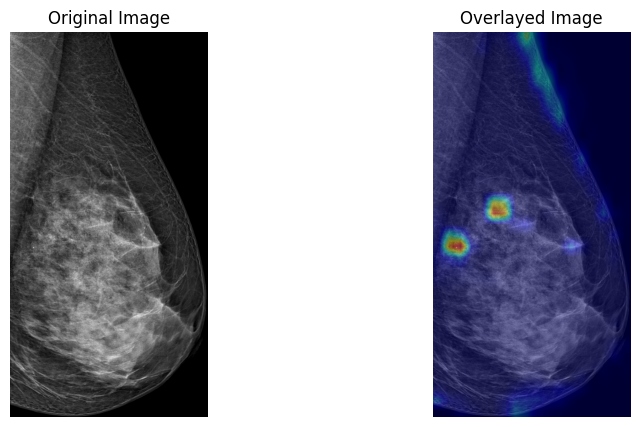

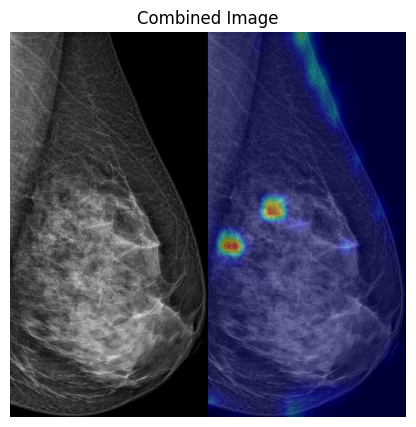

In [1]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torch.autograd import Function
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the Grad-CAM++ implementation
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_backward_hook(backward_hook))

    def generate_heatmap(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        target = output[:, target_class]
        target.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam -= np.min(cam)
        cam /= np.max(cam)
        return cam

    def __del__(self):
        for hook in self.hooks:
            hook.remove()

# Preprocess the input image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = transform(image).unsqueeze(0)
    return image

# Overlay the heatmap on the original image
def apply_heatmap(original_image, heatmap):
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlayed_image = cv2.addWeighted(original_image, 0.6, heatmap, 0.4, 0)
    return overlayed_image

# Load a pre-trained ConvNeXt Small model and set it to evaluation mode
model = models.convnext_small(pretrained=True)
model.eval()

# Modify the fully connected layer to match the number of classes in your model
num_classes = 1  # Change this to the number of classes your model was trained on
model.classifier[2] = torch.nn.Linear(model.classifier[2].in_features, num_classes)

# Load your custom model weights if needed and handle the 'module.' prefix
state_dict = torch.load('/home/castrechini/projects/bac_project/results/convnextsmall/2024-05-15_22-51-11/fold0/weights.pth')
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  # remove 'module.' prefix
    else:
        new_state_dict[k] = v
model.load_state_dict(new_state_dict)

# Initialize Grad-CAM++ with the target layer (e.g., features[-1] of ConvNeXt Small)
gradcam = GradCAMPlusPlus(model, model.features[-1])
gradcam.hook_layers()

# Load and preprocess an input image
image_path = '/home/castrechini/projects/bac_project/src/data/mlo.png'
input_image = preprocess_image(image_path)

# Generate the Grad-CAM++ heatmap
heatmap = gradcam.generate_heatmap(input_image, target_class=None)

# Load the original image for visualization
original_image = cv2.imread(image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Resize heatmap to match original image size
heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))

# Apply heatmap directly to the original image
overlayed_image = apply_heatmap(original_image, heatmap_resized)

# Save the individual images
cv2.imwrite('original_image.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))
cv2.imwrite('overlayed_image.png', cv2.cvtColor(overlayed_image, cv2.COLOR_RGB2BGR))

# Plot the original image and the overlayed image separately
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(overlayed_image)
plt.title('Overlayed Image')
plt.axis('off')
plt.show()

# Combine the original image and the overlayed image
combined_image = np.hstack((original_image, overlayed_image))

# Plot the combined image
plt.figure(figsize=(10, 5))
plt.imshow(combined_image)
plt.title('Combined Image')
plt.axis('off')
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torch.autograd import Function
import cv2
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import Saliency, IntegratedGradients

# Define the Grad-CAM++ implementation
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_backward_hook(backward_hook))

    def generate_heatmap(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        target = output[:, target_class]
        target.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam -= np.min(cam)
        cam /= np.max(cam)
        return cam

    def __del__(self):
        for hook in self.hooks:
            hook.remove()

# Preprocess the input image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = transform(image).unsqueeze(0)
    return image

# Overlay the heatmap on the original image
def apply_heatmap(original_image, heatmap):
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlayed_image = cv2.addWeighted(original_image, 0.6, heatmap, 0.4, 0)
    return overlayed_image

# Visualize intermediate feature maps
def plot_feature_maps(model, input_image, target_layer):
    feature_maps = []

    def hook_fn(module, input, output):
        feature_maps.append(output.cpu().data.numpy())

    hook = target_layer.register_forward_hook(hook_fn)
    _ = model(input_image)
    hook.remove()

    fig, axs = plt.subplots(1, len(feature_maps), figsize=(20, 5))
    for i, fmap in enumerate(feature_maps):
        axs[i].imshow(np.mean(fmap[0], axis=0), cmap='viridis')
        axs[i].axis('off')
    plt.show()

# Plot histogram of activations
def plot_histogram_of_activations(activations):
    plt.hist(activations.ravel(), bins=50)
    plt.title('Histogram of Activations')
    plt.xlabel('Activation Value')
    plt.ylabel('Frequency')
    plt.show()

# Bounding box utility
def draw_bounding_box(image, bbox, label, color=(0, 255, 0)):
    cv2.rectangle(image, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
    cv2.putText(image, label, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

# Load a pre-trained ConvNeXt Small model and set it to evaluation mode
model = models.convnext_small(pretrained=True)
model.eval()

# Modify the fully connected layer to match the number of classes in your model
num_classes = 1  # Change this to the number of classes your model was trained on
model.classifier[2] = torch.nn.Linear(model.classifier[2].in_features, num_classes)

# Load your custom model weights if needed and handle the 'module.' prefix
state_dict = torch.load('/home/castrechini/projects/bac_project/results/convnextsmall/2024-05-15_22-51-11/fold0/weights.pth')
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  # remove 'module.' prefix
    else:
        new_state_dict[k] = v
model.load_state_dict(new_state_dict)

# Initialize Grad-CAM++ with the target layer (e.g., features[-1] of ConvNeXt Small)
gradcam = GradCAMPlusPlus(model, model.features[-1])
gradcam.hook_layers()

# Load and preprocess an input image
image_path = '/home/castrechini/projects/bac_project/dataset/processed_hbb/exams_with_vascular_calcs/4500282400mr.png'
input_image = preprocess_image(image_path)

# Generate the Grad-CAM++ heatmap
heatmap = gradcam.generate_heatmap(input_image, target_class=None)

# Get prediction and probability
output = model(input_image)
probabilities = torch.nn.functional.softmax(output, dim=1)
predicted_class = torch.argmax(probabilities, dim=1).item()
predicted_prob = probabilities[0, predicted_class].item()

# Load the original image for visualization
original_image = cv2.imread(image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Resize heatmap to match original image size
heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))

# Apply heatmap directly to the original image
overlayed_image = apply_heatmap(original_image, heatmap_resized)

# Annotate the images with predicted class and probability
annotated_original_image = original_image.copy()
annotated_overlayed_image = overlayed_image.copy()
cv2.putText(annotated_original_image, f'Class: {predicted_class}, Prob: {predicted_prob:.2f}', (10, 30), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
cv2.putText(annotated_overlayed_image, f'Class: {predicted_class}, Prob: {predicted_prob:.2f}', (10, 30), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

# Saliency Map
saliency = Saliency(model)
saliency_map = saliency.attribute(input_image, target=predicted_class).squeeze().cpu().data.numpy()
saliency_map = np.maximum(saliency_map, 0)
saliency_map /= saliency_map.max()

# Integrated Gradients
integrated_gradients = IntegratedGradients(model)
ig_attr = integrated_gradients.attribute(input_image, target=predicted_class).squeeze().cpu().data.numpy()
ig_attr = np.maximum(ig_attr, 0)
ig_attr /= ig_attr.max()

# Ensure saliency_map and ig_attr are 2D arrays for proper display
if saliency_map.ndim == 3:
    saliency_map = np.mean(saliency_map, axis=0)
if ig_attr.ndim == 3:
    ig_attr = np.mean(ig_attr, axis=0)

# Save the individual images
cv2.imwrite('original_image.png', cv2.cvtColor(annotated_original_image, cv2.COLOR_RGB2BGR))
cv2.imwrite('overlayed_image.png', cv2.cvtColor(annotated_overlayed_image, cv2.COLOR_RGB2BGR))

# Plot the original image and the overlayed image separately
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(annotated_original_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(annotated_overlayed_image)
plt.title('Overlayed Image')
plt.axis('off')
plt.show()

# Combine the original image and the overlayed image
combined_image = np.hstack((annotated_original_image, annotated_overlayed_image))

# Plot the combined image
plt.figure(figsize=(10, 5))
plt.imshow(combined_image)
plt.title('Combined Image')
plt.axis('off')
plt.show()

# Plot the saliency map
plt.figure(figsize=(5, 5))
plt.imshow(saliency_map, cmap='hot')
plt.title('Saliency Map')
plt.axis('off')
plt.show()

# Plot the integrated gradients map
plt.figure(figsize=(5, 5))
plt.imshow(ig_attr, cmap='hot')
plt.title('Integrated Gradients')
plt.axis('off')
plt.show()

# Plot histogram of activations
plot_histogram_of_activations(heatmap)

# Visualize intermediate feature maps
plot_feature_maps(model, input_image, model.features[-1])

# Example of bounding box (assuming coordinates are known or detected)
bbox = [50, 50, 200, 200]  # Example coordinates
label = "ROI"
annotated_original_image_with_bbox = annotated_original_image.copy()
draw_bounding_box(annotated_original_image_with_bbox, bbox, label)
plt.figure(figsize=(5, 5))
plt.imshow(annotated_original_image_with_bbox)
plt.title('Original Image with Bounding Box')
plt.axis('off')
plt.show()


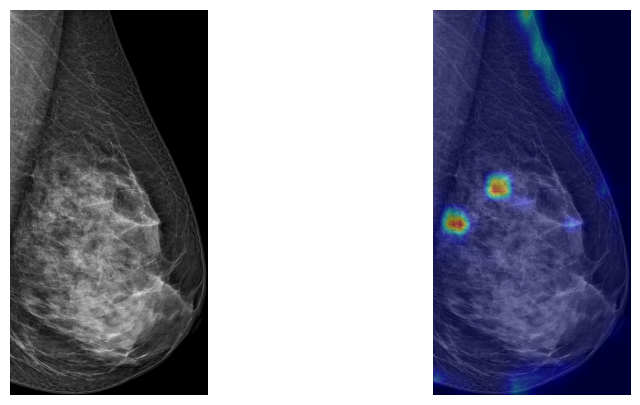

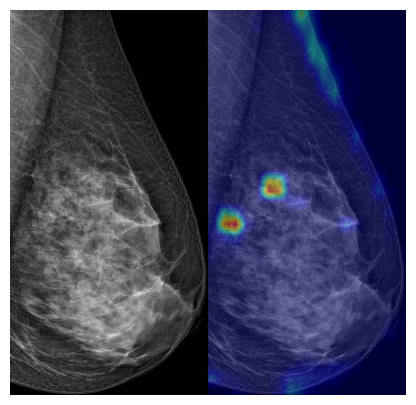

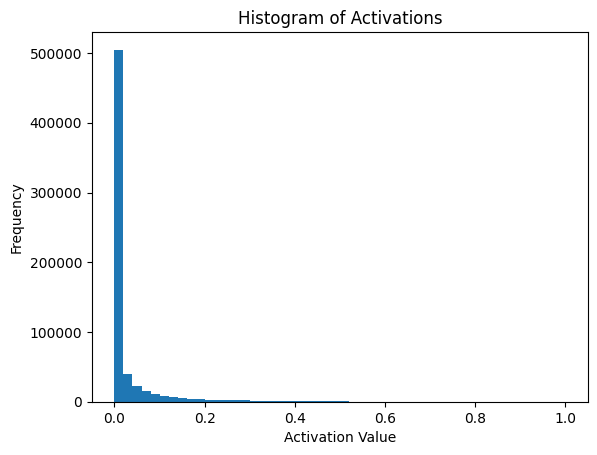

In [2]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torch.autograd import Function
import cv2
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import Saliency, IntegratedGradients

# Define the Grad-CAM++ implementation
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_backward_hook(backward_hook))

    def generate_heatmap(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        target = output[:, target_class]
        target.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam -= np.min(cam)
        cam /= np.max(cam)
        return cam

    def __del__(self):
        for hook in self.hooks:
            hook.remove()

# Preprocess the input image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = transform(image).unsqueeze(0)
    return image

# Overlay the heatmap on the original image
def apply_heatmap(original_image, heatmap):
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlayed_image = cv2.addWeighted(original_image, 0.6, heatmap, 0.4, 0)
    return overlayed_image

# Visualize intermediate feature maps
def plot_feature_maps(model, input_image, target_layer):
    feature_maps = []

    def hook_fn(module, input, output):
        feature_maps.append(output.cpu().data.numpy())

    hook = target_layer.register_forward_hook(hook_fn)
    _ = model(input_image)
    hook.remove()

    num_feature_maps = len(feature_maps)
    fig, axs = plt.subplots(1, num_feature_maps, figsize=(20, 5))
    if num_feature_maps == 1:
        axs = [axs]
    for i, fmap in enumerate(feature_maps):
        axs[i].imshow(np.mean(fmap[0], axis=0), cmap='viridis')
        axs[i].axis('off')
    plt.show()

# Plot histogram of activations
def plot_histogram_of_activations(activations):
    plt.hist(activations.ravel(), bins=50)
    plt.title('Histogram of Activations')
    plt.xlabel('Activation Value')
    plt.ylabel('Frequency')
    plt.show()

# Bounding box utility
def draw_bounding_box(image, bbox, label, color=(0, 255, 0)):
    cv2.rectangle(image, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
    cv2.putText(image, label, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

# Load a pre-trained ConvNeXt Small model and set it to evaluation mode
model = models.convnext_small(pretrained=True)
model.eval()

# Modify the fully connected layer to match the number of classes in your model
num_classes = 1  # Change this to the number of classes your model was trained on
model.classifier[2] = torch.nn.Linear(model.classifier[2].in_features, num_classes)

# Load your custom model weights if needed and handle the 'module.' prefix
state_dict = torch.load('/home/castrechini/projects/bac_project/results/convnextsmall/2024-05-15_22-51-11/fold0/weights.pth')
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  # remove 'module.' prefix
    else:
        new_state_dict[k] = v
model.load_state_dict(new_state_dict)

# Initialize Grad-CAM++ with the target layer (e.g., features[-1] of ConvNeXt Small)
gradcam = GradCAMPlusPlus(model, model.features[-1])
gradcam.hook_layers()

# Load and preprocess an input image
image_path = '/home/castrechini/projects/bac_project/src/data/mlo.png'
input_image = preprocess_image(image_path)

# Generate the Grad-CAM++ heatmap
heatmap = gradcam.generate_heatmap(input_image, target_class=None)

# Get prediction and probability
output = model(input_image)
probabilities = torch.nn.functional.softmax(output, dim=1)
predicted_class = torch.argmax(probabilities, dim=1).item()
predicted_prob = probabilities[0, predicted_class].item()

# Load the original image for visualization
original_image = cv2.imread(image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Resize heatmap to match original image size
heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))

# Apply heatmap directly to the original image
overlayed_image = apply_heatmap(original_image, heatmap_resized)

# Annotate the images with predicted class and probability
annotated_original_image = original_image.copy()
annotated_overlayed_image = overlayed_image.copy()
# cv2.putText(annotated_original_image, f'Class: {predicted_class}, Prob: {predicted_prob:.2f}', (10, 30), 
            # cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
# cv2.putText(annotated_overlayed_image, f'Class: {predicted_class}, Prob: {predicted_prob:.2f}', (10, 30), 
            # cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

# Saliency Map
# saliency = Saliency(model)
# saliency_map = saliency.attribute(input_image, target=predicted_class).squeeze().cpu().data.numpy()
# saliency_map = np.maximum(saliency_map, 0)
# saliency_map /= saliency_map.max()

# Integrated Gradients
# integrated_gradients = IntegratedGradients(model)
# ig_attr = integrated_gradients.attribute(input_image, target=predicted_class).squeeze().cpu().data.numpy()
# ig_attr = np.maximum(ig_attr, 0)
# ig_attr /= ig_attr.max()

# Ensure saliency_map and ig_attr are 2D arrays for proper display
# if saliency_map.ndim == 3:
#     saliency_map = np.mean(saliency_map, axis=0)
# if ig_attr.ndim == 3:
#     ig_attr = np.mean(ig_attr, axis=0)

# Enhance visibility by scaling up the values
# saliency_map = np.uint8(255 * saliency_map)
# ig_attr = np.uint8(255 * ig_attr)

# Save the individual images
cv2.imwrite('original_image.png', cv2.cvtColor(annotated_original_image, cv2.COLOR_RGB2BGR))
cv2.imwrite('overlayed_image.png', cv2.cvtColor(annotated_overlayed_image, cv2.COLOR_RGB2BGR))

# Plot the original image and the overlayed image separately
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(annotated_original_image)
#plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(annotated_overlayed_image)
#plt.title('Overlayed Image')
plt.axis('off')
plt.show()

# Combine the original image and the overlayed image
combined_image = np.hstack((annotated_original_image, annotated_overlayed_image))

# Plot the combined image
plt.figure(figsize=(10, 5))
plt.imshow(combined_image)
#plt.title('Combined Image')
plt.axis('off')
plt.show()

# Plot the saliency map
# plt.figure(figsize=(5, 5))
# plt.imshow(saliency_map, cmap='hot')
# plt.title('Saliency Map')
# plt.axis('off')
# plt.show()

# Plot the integrated gradients map
# plt.figure(figsize=(5, 5))
# plt.imshow(ig_attr, cmap='hot')
# plt.title('Integrated Gradients')
# plt.axis('off')
# plt.show()

# Plot histogram of activations
plot_histogram_of_activations(heatmap)

# Visualize intermediate feature maps
# plot_feature_maps(model, input_image, model.features[-1])

# Example of bounding box (assuming coordinates are known or detected)
# bbox = [50, 50, 200, 200]  # Example coordinates
# label = "ROI"
# annotated_original_image_with_bbox = annotated_original_image.copy()
# draw_bounding_box(annotated_original_image_with_bbox, bbox, label)
# plt.figure(figsize=(5, 5))
# plt.imshow(annotated_original_image_with_bbox)
# plt.title('Original Image with Bounding Box')
# plt.axis('off')
# plt.show()
